
Dataset Preview
   user_id  watch_hours_per_week  login_frequency_per_week  \
0        1                  7.24                         6   
1        2                  5.65                        11   
2        3                  7.62                         0   
3        4                  9.81                         7   
4        5                  5.41                        10   

   avg_session_minutes  content_completion_rate  churn  
0                24.22                     0.25      0  
1                55.06                     0.50      0  
2                51.53                     0.94      0  
3                45.61                     0.67      0  
4                43.11                     0.63      0  

Dataset Summary
           user_id  watch_hours_per_week  login_frequency_per_week  \
count  1000.000000           1000.000000               1000.000000   
mean    500.500000              6.052470                  6.425000   
std     288.819436              2.436359 

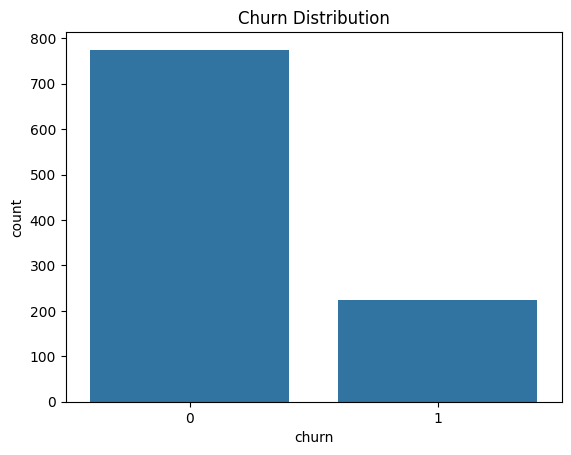


User Segments
segment
1    359
2    328
0    313
Name: count, dtype: int64


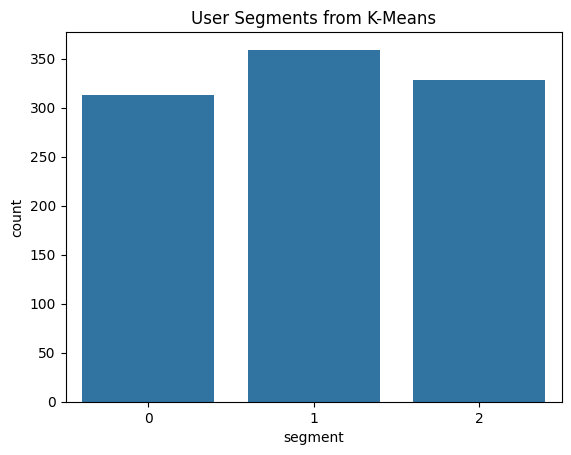


Segment vs Churn Table
churn      0    1
segment          
0        294   19
1        281   78
2        200  128

Baseline Model Results
                 Model  Accuracy  Precision    Recall  F1 Score  \
0  Logistic Regression      0.79   0.600000  0.319149  0.416667   
1        Random Forest      0.80   0.574468  0.574468  0.574468   

         Approach  
0  Without Hybrid  
1  Without Hybrid  

Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.93      0.87       153
           1       0.60      0.32      0.42        47

    accuracy                           0.79       200
   macro avg       0.71      0.63      0.64       200
weighted avg       0.77      0.79      0.76       200



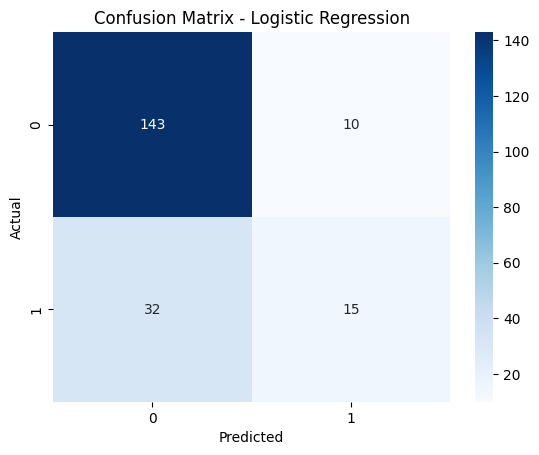


Model: Random Forest
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       153
           1       0.58      0.53      0.56        47

    accuracy                           0.80       200
   macro avg       0.72      0.71      0.71       200
weighted avg       0.79      0.80      0.80       200



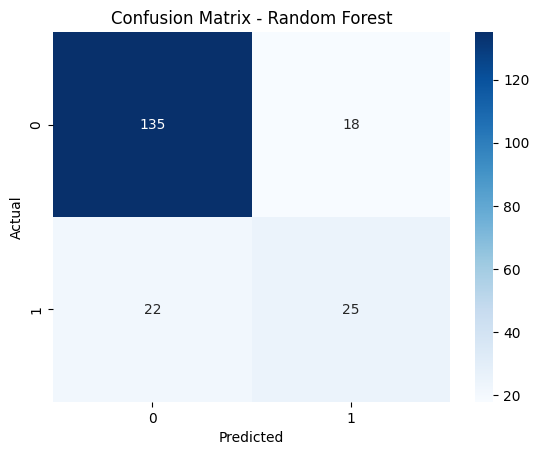


Hybrid Model Results
                 Model  Accuracy  Precision    Recall  F1 Score  \
0  Logistic Regression      0.79   0.600000  0.319149  0.416667   
1        Random Forest      0.80   0.581395  0.531915  0.555556   

          Approach  
0  Hybrid Learning  
1  Hybrid Learning  

Final Model Comparison
                 Model  Accuracy  Precision    Recall  F1 Score  \
0  Logistic Regression      0.79   0.600000  0.319149  0.416667   
1        Random Forest      0.80   0.574468  0.574468  0.574468   
0  Logistic Regression      0.79   0.600000  0.319149  0.416667   
1        Random Forest      0.80   0.581395  0.531915  0.555556   

          Approach  
0   Without Hybrid  
1   Without Hybrid  
0  Hybrid Learning  
1  Hybrid Learning  


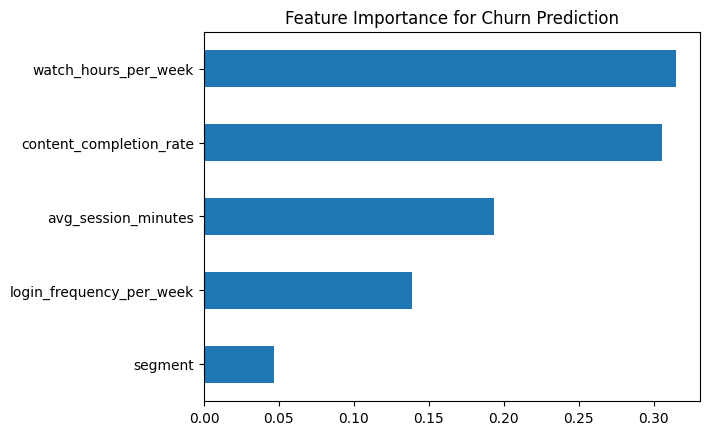

In [8]:
# =============================
# 1 Import Libraries
# =============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report


# =============================
# 2 Load Dataset
# =============================

# Updated to fetch data directly from a public GitHub URL for device-agnostic execution.
# If this URL changes or the repository becomes private, please update this link.
github_csv_url = "https://raw.githubusercontent.com/Vrishketan/Report-Assignement/main/streaming_churn_dataset_1000_users.csv"

try:
    response = requests.get(github_csv_url)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    csv_content = StringIO(response.text)
    df = pd.read_csv(csv_content)
except requests.exceptions.RequestException as e:
    print(f"Error fetching data from GitHub: {e}")
    raise # Re-raise the exception after printing for better visibility

print("\nDataset Preview")
print(df.head())

print("\nDataset Summary")
print(df.describe())


# =============================
# 3 Exploratory Analytics
# =============================

print("\nChurn Distribution")
print(df['churn'].value_counts())

sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()


# =============================
# 4 Feature Selection
# =============================

features = df[['watch_hours_per_week',
               'login_frequency_per_week',
               'avg_session_minutes',
               'content_completion_rate']]

target = df['churn']


# =============================
# 5 Data Scaling
# =============================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


# =============================
# 6 Unsupervised Learning
# K-Means Clustering
# =============================

kmeans = KMeans(n_clusters=3, random_state=42)

df['segment'] = kmeans.fit_predict(X_scaled)

print("\nUser Segments")
print(df['segment'].value_counts())

sns.countplot(x='segment', data=df)
plt.title("User Segments from K-Means")
plt.show()


# =============================
# 7 Segment vs Churn Analytics
# =============================

segment_analysis = pd.crosstab(df['segment'], df['churn'])

print("\nSegment vs Churn Table")
print(segment_analysis)


# =============================
# 8 BASELINE MODELS
# (Without Hybrid Learning)
# =============================

X = features
y = target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

baseline_models = {

    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=200)

}

baseline_results = []

for name, model in baseline_models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    baseline_results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

baseline_df = pd.DataFrame(
    baseline_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

baseline_df["Approach"] = "Without Hybrid"

print("\nBaseline Model Results")
print(baseline_df)


# =============================
# 9 HYBRID LEARNING MODELS
# =============================

X_hybrid = df[['watch_hours_per_week',
               'login_frequency_per_week',
               'avg_session_minutes',
               'content_completion_rate',
               'segment']]

y_hybrid = df['churn']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hybrid, y_hybrid, test_size=0.2, random_state=42
)

hybrid_models = {

    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=200)

}

hybrid_results = []

for name, model in hybrid_models.items():

    model.fit(X_train_h, y_train_h)
    y_pred = model.predict(X_test_h)

    hybrid_results.append([
        name,
        accuracy_score(y_test_h, y_pred),
        precision_score(y_test_h, y_pred),
        recall_score(y_test_h, y_pred),
        f1_score(y_test_h, y_pred)
    ])

    print("\nModel:", name)
    print(classification_report(y_test_h, y_pred))

    cm = confusion_matrix(y_test_h, y_pred);

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


hybrid_df = pd.DataFrame(
    hybrid_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

hybrid_df["Approach"] = "Hybrid Learning"

print("\nHybrid Model Results")
print(hybrid_df)


# =============================
# 10 Model Comparison Table
# =============================

comparison = pd.concat([baseline_df, hybrid_df])

print("\nFinal Model Comparison")
print(comparison)


# =============================
# 11 Feature Importance
# =============================

rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train_h, y_train_h)

importance = pd.Series(
    rf.feature_importances_,
    index=X_hybrid.columns
)

importance.sort_values().plot(
    kind="barh",
    title="Feature Importance for Churn Prediction"
)

plt.show()